In [2]:
import matplotlib.pyplot as plt
import numpy as np

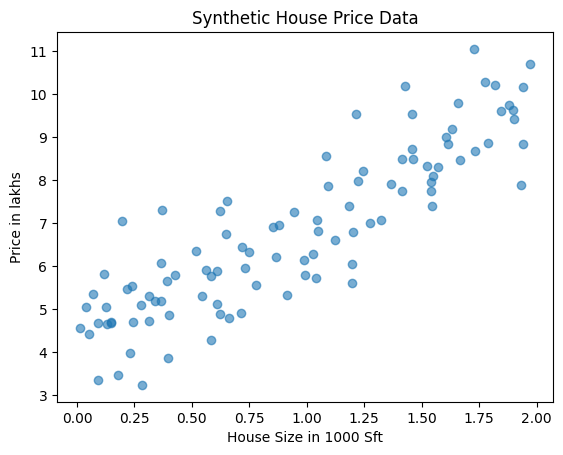

In [3]:
## Gradient Descent with Linear Regression
import numpy as np
import matplotlib.pyplot as plt

# Generate Synthetic data

np.random.seed(42)
X = 2 * np.random.rand(100,1)  #house Size (sqrft)
y = 4 + 3 *X + np.random.randn(100,1) #price = 4 + 3 * size + noise

plt.scatter(X, y, alpha=0.6)
plt.xlabel("House Size in 1000 Sft")
plt.ylabel("Price in lakhs")
plt.title("Synthetic House Price Data")
plt.show()

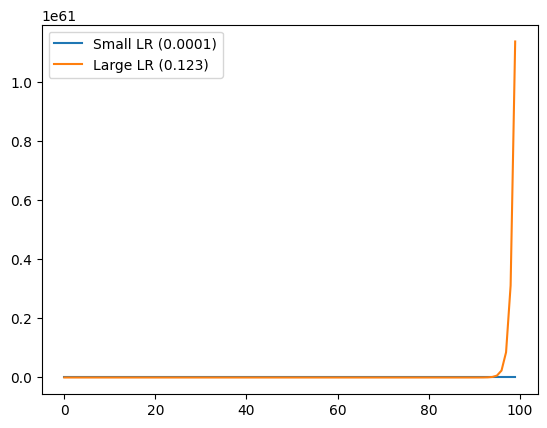

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated dataset (House size vs Price)
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([150, 300, 450, 600, 750], dtype=float)

# Gradient Descent with fixed learning rate
def gradient_descent(X, y, lr=0.01, iterations=50):
    m, c = 0, 0  # initial slope and intercept
    n = len(X)
    costs = []

    for _ in range(iterations):
        y_pred = m * X + c
        error = y_pred - y
        cost = np.mean(error ** 2)
        costs.append(cost)

        # Gradients
        dm = (2/n) * np.dot(error, X)
        dc = (2/n) * np.sum(error)

        # Update
        m -= lr * dm
        c -= lr * dc

    return m, c, costs

# Case 1: Too small LR
m1, c1, costs1 = gradient_descent(X, y, lr=0.0001, iterations=100)
# Case 2: Too large LR
m2, c2, costs2 = gradient_descent(X, y, lr=0.123, iterations=100)

plt.plot(costs1, label="Small LR (0.0001)")
plt.plot(costs2, label="Large LR (0.123)")
plt.legend()
plt.show()

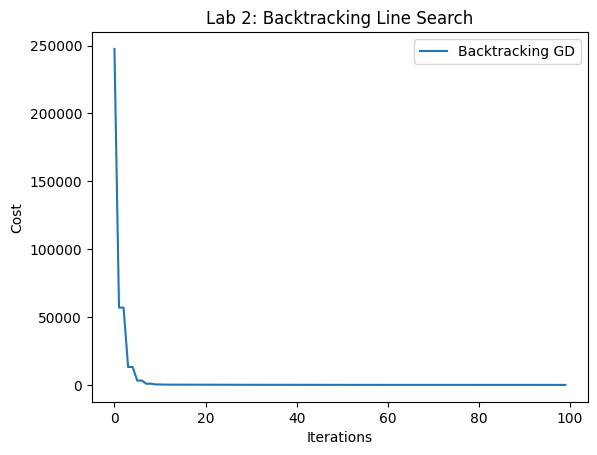

Final Model: y = 147.58x + 8.36


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated dataset (House size vs Price)
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([150, 300, 450, 600, 750], dtype=float)

def compute_cost(X, y, m, c):
    y_pred = m * X + c
    return np.mean((y - y_pred) ** 2)

# Gradient Descent with fixed learning rate
def gradient_descent_backtracking(X, y, initial_lr=0.01, iterations=50, shrink_factor = 0.5):
    m, c = 0, 0  # initial slope and intercept
    n = len(X)
    costs = []

    for _ in range(iterations):
        y_pred = m * X + c
        error = y_pred - y
        cost = np.mean(error ** 2)
        costs.append(cost)

        # Gradients
        dm = (2/n) * np.dot(error, X)
        dc = (2/n) * np.sum(error)

        # # Update
        # m -= lr * dm
        # c -= lr * dc

        # Backtracking
        step = initial_lr
        cost = compute_cost(X, y, m, c)
        while True:
            new_m = m - step * dm
            new_c = c - step * dc
            new_cost = compute_cost(X, y, new_m, new_c)

            if new_cost < cost:
                m, c = new_m, new_c
                cost = new_cost
                break
            else:
                step *= shrink_factor #reduce step size
        
        costs.append(cost)

    return m, c, costs

# Run Backtracking GD
m_bt, c_bt, costs_bt = gradient_descent_backtracking(X, y, initial_lr=0.5)

plt.plot(costs_bt, label="Backtracking GD")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Lab 2: Backtracking Line Search")
plt.legend()
plt.show()

print(f"Final Model: y = {m_bt:.2f}x + {c_bt:.2f}")
